## 4. External Variable Inspection

These plots z-score the raw curated predictor columns against CPI YoY for visual inspection only. Use the stationarity-aware CCF and Granger tables below for correlation evidence.

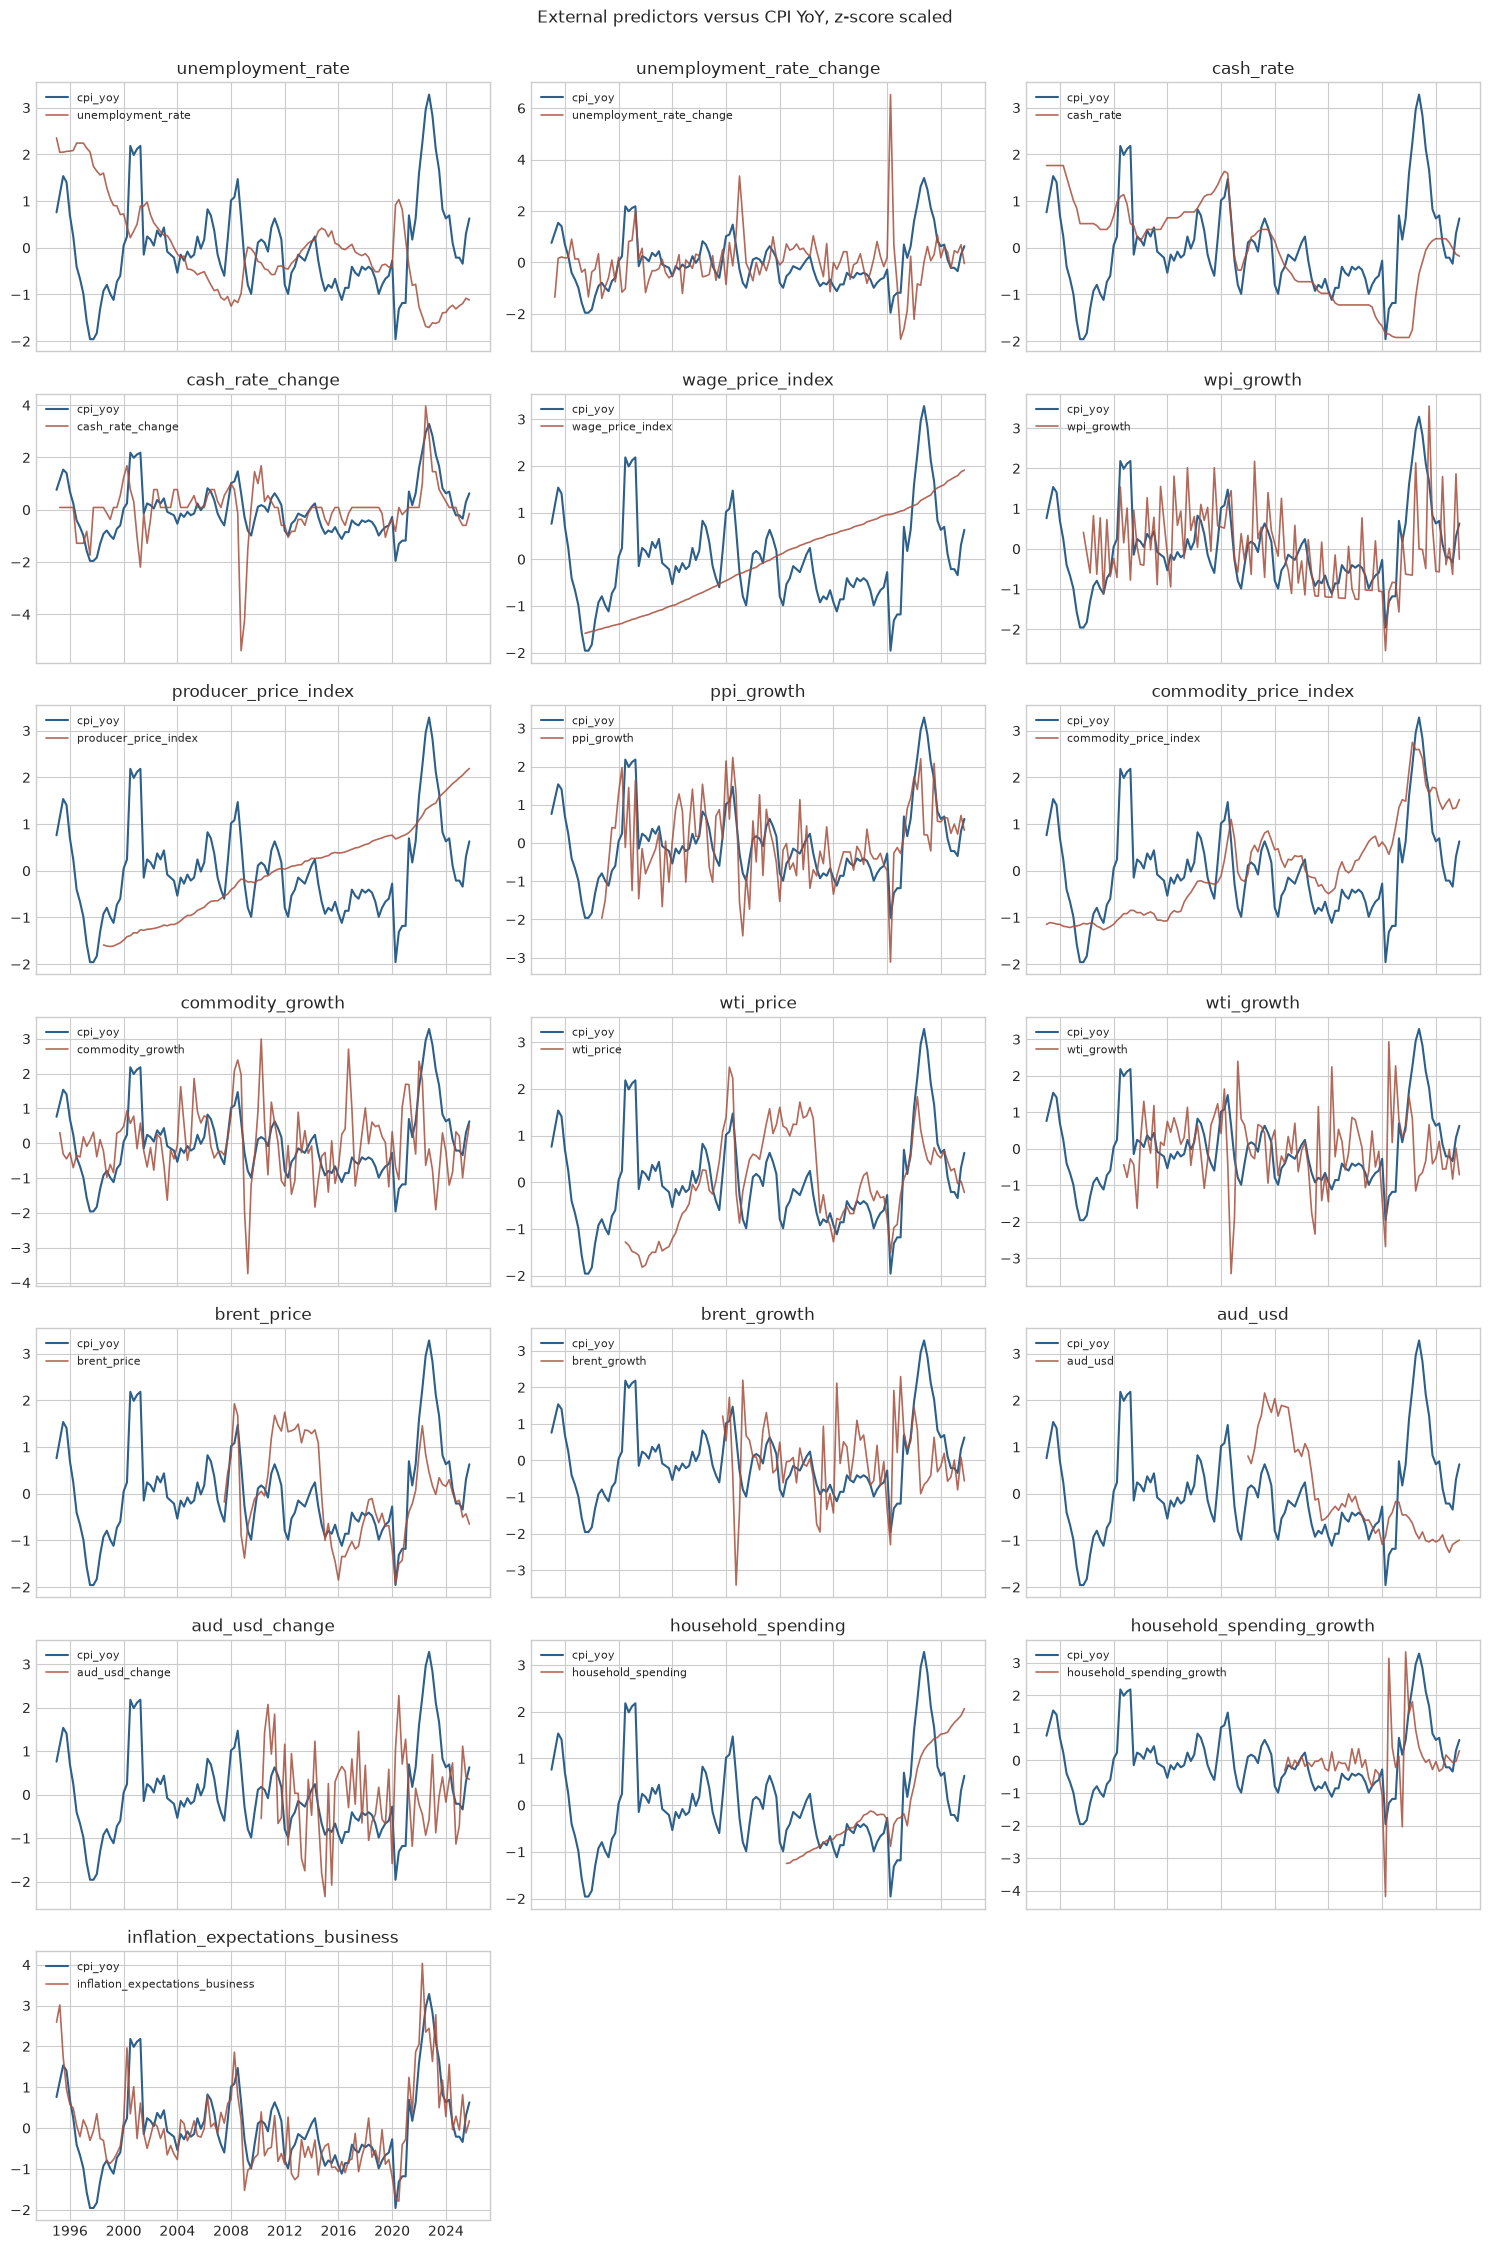

,external_base_variable
0,unemployment_rate
1,unemployment_rate_change
2,cash_rate
3,cash_rate_change
4,wage_price_index
5,wpi_growth
6,producer_price_index
7,ppi_growth
8,commodity_price_index
9,commodity_growth


,lagged_feature_from_src_features
0,cash_rate_lag1
1,cash_rate_lag2
2,cash_rate_lag4
3,unemployment_rate_lag1
4,unemployment_rate_lag2
5,unemployment_rate_lag4
6,wpi_growth_lag1
7,wpi_growth_lag2
8,ppi_growth_lag1
9,ppi_growth_lag2


In [6]:
cpi_family_exclusion_cols = set(CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS)
EXTERNAL_BASE_COLS = [
    column for column in df_model.columns
    if column not in {'quarter', *cpi_family_exclusion_cols} and '_lag' not in column
]
EXTERNAL_LAGGED_FEATURES = [
    column for column in df_model.columns
    if '_lag' in column and re.sub(r'_lag\d+$', '', column) not in cpi_family_exclusion_cols
]

def zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return numeric * np.nan
    return (numeric - numeric.mean()) / std


n_cols = 3
n_rows = int(np.ceil(len(EXTERNAL_BASE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.2 * n_rows)), sharex=True)
axes = np.array(axes).reshape(-1)
for ax, column in zip(axes, EXTERNAL_BASE_COLS):
    ax.plot(df['quarter_start'], zscore(df[TARGET]), label=TARGET, color='#2c5f8a', linewidth=1.5)
    ax.plot(df['quarter_start'], zscore(df[column]), label=column, color='#a64f3c', linewidth=1.2, alpha=0.85)
    ax.set_title(column)
    ax.legend(fontsize=8)
for ax in axes[len(EXTERNAL_BASE_COLS):]:
    ax.axis('off')
fig.suptitle('External predictors versus CPI YoY, z-score scaled', y=1.002)
fig.tight_layout()
plt.show()

display(pd.DataFrame({'external_base_variable': EXTERNAL_BASE_COLS}))
display(pd.DataFrame({'lagged_feature_from_src_features': EXTERNAL_LAGGED_FEATURES}))